In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [ ]:

## Step 1: Load and Preprocess Data
# Load training and test datasets
df_train = pd.read_csv('trainset.csv')
df_test = pd.read_csv('testset.csv')


In [ ]:
# Use closing prices
train_prices = df_train['Close'].values.reshape(-1, 1)
test_prices = df_test['Close'].values.reshape(-1, 1)

In [ ]:

# Normalize the data based on training set only
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train_prices)
scaled_test = scaler.transform(test_prices)

In [ ]:
# Create sequences
def create_sequences(data, seq_length):
    x = []
    y = []
    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(x), np.array(y)

seq_length = 60
x_train, y_train = create_sequences(scaled_train, seq_length)
x_test, y_test = create_sequences(scaled_test, seq_length)


In [ ]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((1199, 60, 1), (1199, 1), (65, 60, 1), (65, 1))

In [ ]:
# Convert to PyTorch tensors
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

In [ ]:
# Create dataset and dataloader
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [ ]:
# Define RNN Model
class RNNModel(nn.Module):
  def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
    super(RNNModel, self).__init__()
    self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first = True)
    self.fc = nn.Linear(hidden_size, output_size)

  def forward(self,x):
    out, _ = self.rnn(x)
    out = self.fc(out[:, -1, :])
    return out


In [ ]:
model = RNNModel()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary

# input_size = (batch_size, seq_len, input_size)
summary(model, input_size=(64, 60, 1))

Layer (type:depth-idx)                   Output Shape              Param #
RNNModel                                 [64, 1]                   --
├─RNN: 1-1                               [64, 60, 64]              12,608
├─Linear: 1-2                            [64, 1]                   65
Total params: 12,673
Trainable params: 12,673
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 48.42
Input size (MB): 0.02
Forward/backward pass size (MB): 1.97
Params size (MB): 0.05
Estimated Total Size (MB): 2.03

In [ ]:
model = RNNModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
model = RNNModel()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 20
model.train()
train_losses = []
print('Name:MAHALINGA JEYANTH V')
print('Register number:212224220057')
for epoch in range(epochs):
  epoch_loss = 0
  for x_batch, y_batch in train_loader:
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
    optimizer.zero_grad()
    outputs = model(x_batch)
    loss = criterion(outputs, y_batch)
    loss.backward()
    optimizer.step()
    epoch_loss += loss.item()
  train_losses.append(epoch_loss / len(train_loader))
  print(f"Epoch [{epoch+1}/{epochs}], Loss:{train_losses[-1]:.4f}")

Name:MAHALINGA JEYANTH V
Register number:212224220057
Epoch [1/20], Loss:0.0002
Epoch [2/20], Loss:0.0002
Epoch [3/20], Loss:0.0002
Epoch [4/20], Loss:0.0002
Epoch [5/20], Loss:0.0002
Epoch [6/20], Loss:0.0002
Epoch [7/20], Loss:0.0002
Epoch [8/20], Loss:0.0002
Epoch [9/20], Loss:0.0002
Epoch [10/20], Loss:0.0002
Epoch [11/20], Loss:0.0002
Epoch [12/20], Loss:0.0002
Epoch [13/20], Loss:0.0002
Epoch [14/20], Loss:0.0002
Epoch [15/20], Loss:0.0002
Epoch [16/20], Loss:0.0002
Epoch [17/20], Loss:0.0002
Epoch [18/20], Loss:0.0002
Epoch [19/20], Loss:0.0002
Epoch [20/20], Loss:0.0002


Name: MAHALINGA JEYANTH
Register Number: 212224220057


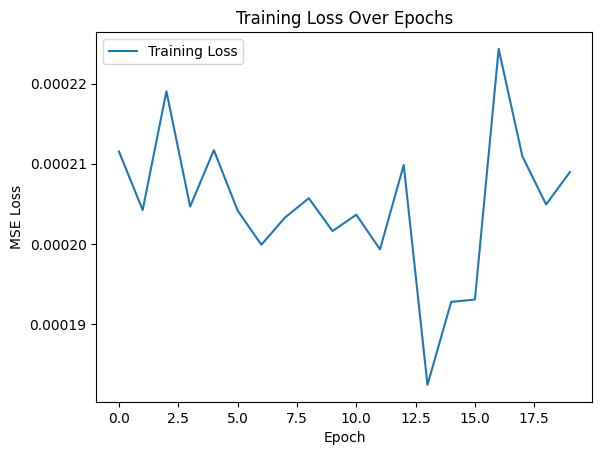

In [ ]:
# Plot training loss
print('Name: MAHALINGA JEYANTH')
print('Register Number: 212224220057')
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.show()

In [ ]:
## Step 4: Make Predictions on Test Set
model.eval()
with torch.no_grad():
    predicted = model(x_test_tensor.to(device)).cpu().numpy()
    actual = y_test_tensor.cpu().numpy()


In [ ]:
# Inverse transform the predictions and actual values
predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(actual)

Name: MAHALINGA JEYANTH V
Register Number: 212224220057


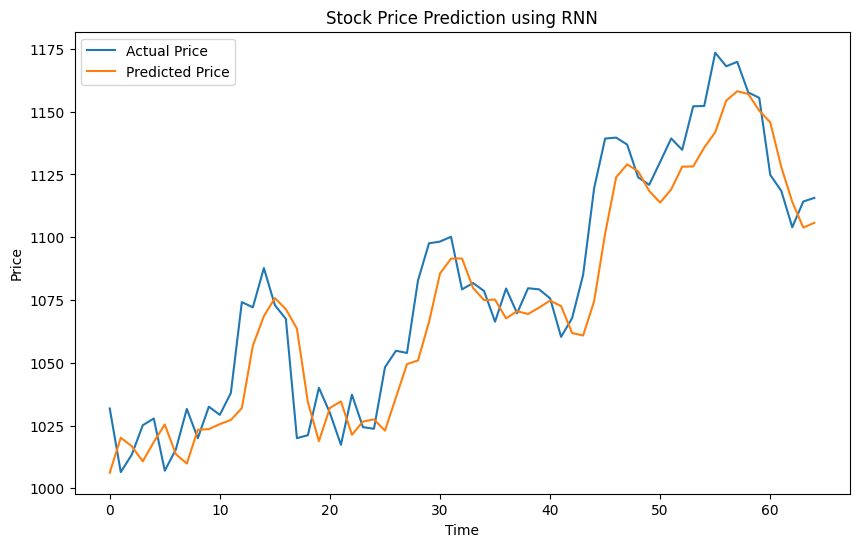

Predicted Price: [1105.7417]
Actual Price: [1115.65]


In [ ]:
# Plot the predictions vs actual prices
print('Name: MAHALINGA JEYANTH V')
print('Register Number: 212224220057')
plt.figure(figsize=(10, 6))
plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Stock Price Prediction using RNN')
plt.legend()
plt.show()
print(f'Predicted Price: {predicted_prices[-1]}')
print(f'Actual Price: {actual_prices[-1]}')